In [ ]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras import layers, activations
from keras import backend as K
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Mount Google Drive so models/plots/CSVs are saved persistently
from google.colab import drive
try:
    drive.mount('/content/drive', force_remount=True)
except:
    print("Drive already mounted, skipping.")



Mounted at /content/drive


Loaded hourly table: (89723, 5) cols: ['air_temp', 'air_pres', 'water_temp', 'wind_dir', 'wind_speed']


,air_temp,air_pres,water_temp,wind_dir,wind_speed
record_time,,,,,
2012-01-01 00:00:00,0.076667,1022.790000,3.863333,96.666667,0.411667
2012-01-01 01:00:00,-0.178333,1022.490000,3.898333,46.600000,0.728333
2012-01-01 02:00:00,-0.551667,1022.336667,3.865000,8.233333,2.636667
2012-01-01 03:00:00,-0.701667,1022.340000,3.900000,30.166667,2.045000
2012-01-01 04:00:00,-0.880000,1022.133333,3.896667,8.666667,2.586667


X_tr: (76240, 24, 5) y_tr: (76240,) | X_te: (13459, 24, 5) y_te: (13459,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 55s 22ms/step - loss: 0.0681 - mae: 0.1475 - rmse: 0.2300
Epoch 2/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 82s 22ms/step - loss: 0.0021 - mae: 0.0340 - rmse: 0.0453
Epoch 3/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 82s 22ms/step - loss: 0.0013 - mae: 0.0273 - rmse: 0.0359
Epoch 4/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 82s 22ms/step - loss: 0.0011 - mae: 0.0252 - rmse: 0.0329
Epoch 5/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 86s 23ms/step - loss: 0.0014 - mae: 0.0274 - rmse: 0.0367
Epoch 6/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 52s 22ms/step - loss: 0.0010 - mae: 0.0248 - rmse: 0.0324
Epoch 7/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 81s 22ms/step - loss: 9.7758e-04 - mae: 0.0238 - rmse: 0.0313
Epoch 8/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 82s 22ms/step - loss: 9.6026e-04 - mae: 0.0235 - rmse: 0.0310
Epoch 9/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 82s 22ms/step - loss: 9.4375e-04 - mae: 0.0234 - rmse: 0.0307
Epoch 10/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 82s 22ms/step - loss: 9.0336e-04 - mae: 0.022

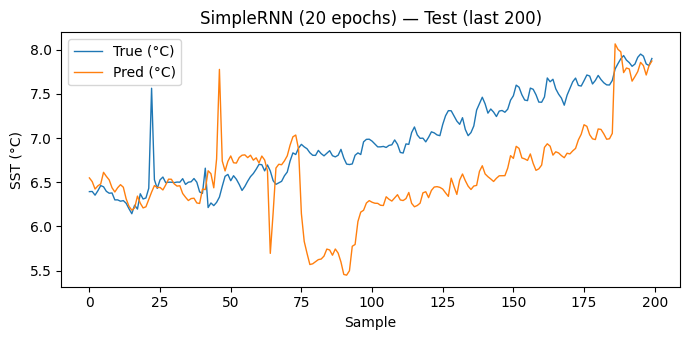

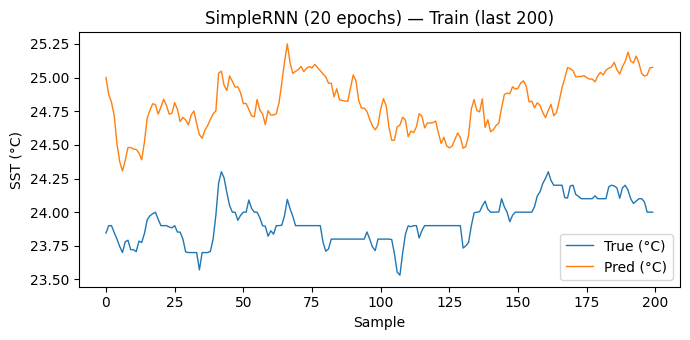


Saved: /content/drive/My Drive/Colab Notebooks/Validation_01/SimpleRNN_by_20epochs.csv
Done ✅ (DT_0001)


In [ ]:
from IPython.display import display
# ==== SimpleRNN — DT_0001 (Incheon) : one-cell pipeline ====CELL 5
import os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dropout, Dense
from tensorflow.keras import layers, activations

# ----------------- CONFIG -----------------
data_name = 1         # DT_0001 (Incheon)
epochs    = 20
WINDOW    = 24

# Auto-unzip if needed (safe no-op if already extracted)
if not os.path.isdir("/content/DT_0001_extracted"):
    os.system('unzip -q "DT_0001.zip" -d "DT_0001_extracted"')

# Output dirs: prefer Drive if mounted, else local /content/outputs
drive_base = "/content/drive/My Drive/Colab Notebooks"
use_drive  = os.path.exists("/content/drive/My Drive")
root_out   = drive_base if use_drive else "/content/outputs"
models_dir = f"{root_out}/Models_0{data_name}"
plots_dir  = f"{root_out}/Plots_0{data_name}"
pred_dir   = f"{root_out}/Prediction_0{data_name}"
val_dir    = f"{root_out}/Validation_0{data_name}"
for d in [models_dir, plots_dir, pred_dir, val_dir]:
    os.makedirs(d, exist_ok=True)

# ----------------- LOADERS (dup-safe) -----------------
def _load_json_hourly(path, keep_cols):
    with open(path, "r") as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    if "record_time" not in df.columns:
        raise ValueError(f"'record_time' missing in {path}")
    df["record_time"] = pd.to_datetime(df["record_time"])
    for c in keep_cols:
        if c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")
    cols = ["record_time"] + [c for c in keep_cols if c in df.columns]
    df = df[cols].set_index("record_time").sort_index().resample("h").mean()
    return df

def _collapse_features(df):
    base = ['sst','air_pres','water_temp','wind_dir','wind_speed']
    df = df.copy(); df.columns = [str(c) for c in df.columns]
    out = {}
    for name in base:
        pick = [c for c in df.columns if (c == name) or c.startswith(name)]
        if pick: out[name] = df[pick].astype(float).mean(axis=1)
    out_df = pd.DataFrame(out, index=df.index).sort_index()
    out_df = out_df[[c for c in base if c in out_df.columns]]
    assert out_df.columns.is_unique
    return out_df

def load_dt0001():
    base = "/content/DT_0001_extracted/MultiFeature_DT_0001"
    if not os.path.isdir(base):
        raise FileNotFoundError(f"Not found: {base}")
    pieces = []
    for year in sorted(os.listdir(base)):
        ypath = os.path.join(base, year)
        if not os.path.isdir(ypath): continue
        yy = str(year)[-2:]
        for fname, keep in [
            (f"air_temp{yy}.json", ["air_temp"]),
            (f"air_pres{yy}.json", ["air_pres"]),
            (f"water_temp{yy}.json", ["water_temp"]),
            (f"wind_dir_spd{yy}.json", ["wind_dir","wind_speed"]),
        ]:
            p = os.path.join(ypath, fname)
            if os.path.exists(p):
                d = _load_json_hourly(p, keep)
                d.columns = [f"{c}_{yy}" for c in d.columns]  # unique suffix
                pieces.append(d)
    if not pieces: raise RuntimeError("No JSON files for DT_0001.")
    raw = pd.concat(pieces, axis=1).sort_index()
    out_df = _collapse_features(raw).bfill().ffill()
    if 'water_temp' in out_df.columns and 'sst' not in out_df.columns:
        out_df = out_df.rename(columns={'water_temp': 'sst'})
    return out_df

# ---- Load
df = load_dt0001()
print("Loaded hourly table:", df.shape, "cols:", list(df.columns))
display(df.head())

# ---- Outlier fix (±3σ -> NaN -> bfill/ffill)
proc = df.copy()
for col in proc.columns:
    s = proc[col].astype(float)
    sd = s.std()
    if sd and not np.isnan(sd):
        mu = s.mean(); lo, hi = mu-3*sd, mu+3*sd
        mask = (s < lo) | (s > hi)
        if np.any(mask.to_numpy()):
            s[mask] = np.nan; s = s.bfill()
    proc[col] = s
proc = proc.ffill()

# ---- Split, scale (fit on train only)
N = len(proc); split = int(N*0.85)
train_df, test_df = proc.iloc[:split], proc.iloc[split:]
scaler_all = MinMaxScaler()
train_scaled = scaler_all.fit_transform(train_df.values)
test_scaled  = scaler_all.transform(test_df.values)
sst_idx = train_df.columns.get_loc("sst")
sst_scaler = MinMaxScaler().fit(train_df.values[:, [sst_idx]])

# ---- Windows
def make_sup(arr, window=24, target_idx=2):
    X, y = [], []
    for i in range(window, len(arr)):
        X.append(arr[i-window:i, :]); y.append(arr[i, target_idx])
    return np.array(X), np.array(y)
X_tr, y_tr = make_sup(train_scaled, WINDOW, sst_idx)
X_te, y_te = make_sup(np.vstack([train_scaled[-WINDOW:], test_scaled]), WINDOW, sst_idx)
print("X_tr:", X_tr.shape, "y_tr:", y_tr.shape, "| X_te:", X_te.shape, "y_te:", y_te.shape)

# ---- SimpleRNN
model = Sequential([
    SimpleRNN(128, return_sequences=True, input_shape=(X_tr.shape[1], X_tr.shape[2])),
    Dropout(0.5),
    layers.Activation(activations.relu),
    SimpleRNN(128),
    Dropout(0.5),
    Dense(1)
])
model.compile(optimizer="adam",
              loss="mse",
              metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse"), "mae"])
history = model.fit(X_tr, y_tr, batch_size=32, epochs=epochs, verbose=1)
# after: history = model.fit(...)
rnn_model = model  # keep a handle to the RNN

# ---- Predict
yhat_tr = model.predict(X_tr, verbose=0).ravel()
yhat_te = model.predict(X_te, verbose=0).ravel()

# ---- Metrics (scaled & °C)
mae_tr_s = float(mean_absolute_error(y_tr, yhat_tr))
mae_te_s = float(mean_absolute_error(y_te, yhat_te))
rmse_tr_s = float(np.sqrt(mean_squared_error(y_tr, yhat_tr)))
rmse_te_s = float(np.sqrt(mean_squared_error(y_te, yhat_te)))
mse_tr_s  = float(mean_squared_error(y_tr, yhat_tr))
mse_te_s  = float(mean_squared_error(y_te, yhat_te))
y_tr_C    = sst_scaler.inverse_transform(y_tr.reshape(-1,1)).ravel()
y_te_C    = sst_scaler.inverse_transform(y_te.reshape(-1,1)).ravel()
yhat_tr_C = sst_scaler.inverse_transform(yhat_tr.reshape(-1,1)).ravel()
yhat_te_C = sst_scaler.inverse_transform(yhat_te.reshape(-1,1)).ravel()
mae_tr_C  = float(mean_absolute_error(y_tr_C, yhat_tr_C))
mae_te_C  = float(mean_absolute_error(y_te_C, yhat_te_C))
rmse_tr_C = float(np.sqrt(mean_squared_error(y_tr_C, yhat_tr_C)))
rmse_te_C = float(np.sqrt(mean_squared_error(y_te_C, yhat_te_C)))
mse_tr_C  = float(mean_squared_error(y_tr_C, yhat_tr_C))
mse_te_C  = float(mean_squared_error(y_te_C, yhat_te_C))
print(f"[SCALED] Train MAE={mae_tr_s:.6f} RMSE={rmse_tr_s:.6f} | Test MAE={mae_te_s:.6f} RMSE={rmse_te_s:.6f}")
print(f"[°C]     Train MAE={mae_tr_C:.4f} RMSE={rmse_tr_C:.4f} | Test MAE={mae_te_C:.4f} RMSE={rmse_te_C:.4f}")

# ---- Save CSVs, plots, model
val_path = f"{val_dir}/SimpleRNN_by_{epochs}epochs.csv"
pd.DataFrame({
    "MAE_train_scaled":[mae_tr_s], "RMSE_train_scaled":[rmse_tr_s],
    "MAE_test_scaled":[mae_te_s],  "RMSE_test_scaled":[rmse_te_s],
    "MAE_train_C":[mae_tr_C],      "RMSE_train_C":[rmse_tr_C],
    "MAE_test_C":[mae_te_C],       "RMSE_test_C":[rmse_te_C],
}).to_csv(val_path, index=False)

pd.DataFrame({
    "y_train_scaled": y_tr, "y_pred_train_scaled": yhat_tr,
    "y_train_C": y_tr_C,    "y_pred_train_C": yhat_tr_C
}).to_csv(f"{pred_dir}/SimpleRNN_by_{epochs}epochs_train.csv", index=False)

pd.DataFrame({
    "y_test_scaled": y_te, "y_pred_test_scaled": yhat_te,
    "y_test_C": y_te_C,    "y_pred_test_C": yhat_te_C
}).to_csv(f"{pred_dir}/SimpleRNN_by_{epochs}epochs_test.csv", index=False)

plt.figure(figsize=(7,3.5))
plt.plot(y_te_C[-200:], label="True (°C)", linewidth=1)
plt.plot(yhat_te_C[-200:], label="Pred (°C)", linewidth=1)
plt.title(f"SimpleRNN ({epochs} epochs) — Test (last 200)")
plt.xlabel("Sample"); plt.ylabel("SST (°C)"); plt.legend(); plt.tight_layout()
plt.savefig(f"{plots_dir}/SimpleRNN_by_{epochs}epochs_test.tiff", dpi=300); plt.show()

plt.figure(figsize=(7,3.5))
plt.plot(y_tr_C[-200:], label="True (°C)", linewidth=1)
plt.plot(yhat_tr_C[-200:], label="Pred (°C)", linewidth=1)
plt.title(f"SimpleRNN ({epochs} epochs) — Train (last 200)")
plt.xlabel("Sample"); plt.ylabel("SST (°C)"); plt.legend(); plt.tight_layout()
plt.savefig(f"{plots_dir}/SimpleRNN_by_{epochs}epochs_train.tiff", dpi=300); plt.show()

model.save(f"{models_dir}/SimpleRNN_by_{epochs}epochs.h5")
print("\nSaved:", val_path)
print("Done ✅ (DT_0001)")


Loaded hourly table: (89833, 5) cols: ['air_temp', 'air_pres', 'water_temp', 'wind_dir', 'wind_speed']


,air_temp,air_pres,water_temp,wind_dir,wind_speed
record_time,,,,,
2012-01-01 00:00:00,0.288333,1027.126667,1.800000,148.233333,1.008333
2012-01-01 01:00:00,-0.010000,1026.815000,1.800000,99.550000,0.656667
2012-01-01 02:00:00,-0.888333,1026.678333,1.800000,73.416667,1.016667
2012-01-01 03:00:00,-1.071186,1026.623729,1.800000,67.389831,0.925424
2012-01-01 04:00:00,-1.788333,1026.518333,1.886667,68.350000,0.570000


X_tr: (76334, 24, 5) y_tr: (76334,) | X_te: (13475, 24, 5) y_te: (13475,)
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2386/2386 ━━━━━━━━━━━━━━━━━━━━ 55s 22ms/step - loss: 0.0760 - mae: 0.1510 - rmse: 0.2402
Epoch 2/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 50s 21ms/step - loss: 0.0024 - mae: 0.0367 - rmse: 0.0493
Epoch 3/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 83s 22ms/step - loss: 0.0017 - mae: 0.0308 - rmse: 0.0417
Epoch 4/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 81s 21ms/step - loss: 0.0016 - mae: 0.0283 - rmse: 0.0395
Epoch 5/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 82s 22ms/step - loss: 0.0015 - mae: 0.0276 - rmse: 0.0385
Epoch 6/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 83s 22ms/step - loss: 0.0021 - mae: 0.0329 - rmse: 0.0456
Epoch 7/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 82s 22ms/step - loss: 0.0015 - mae: 0.0271 - rmse: 0.0381
Epoch 8/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 56s 24ms/step - loss: 0.0014 - mae: 0.0271 - rmse: 0.0377
Epoch 9/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 53s 22ms/step - loss: 0.0014 - mae: 0.0263 - rmse: 0.0372
Epoch 10/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 81s 22ms/step - loss: 0.0013 - mae: 0.0256 - rmse: 0.0357
Epoch 11/2

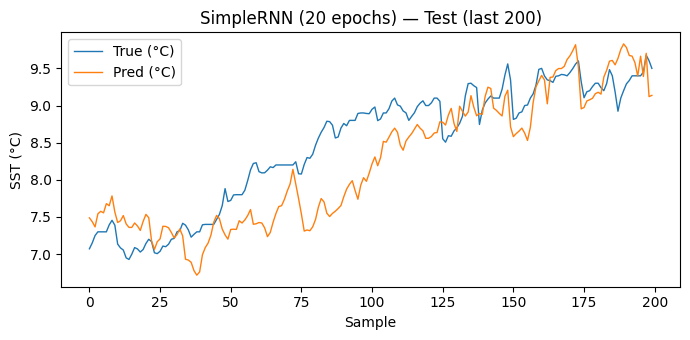

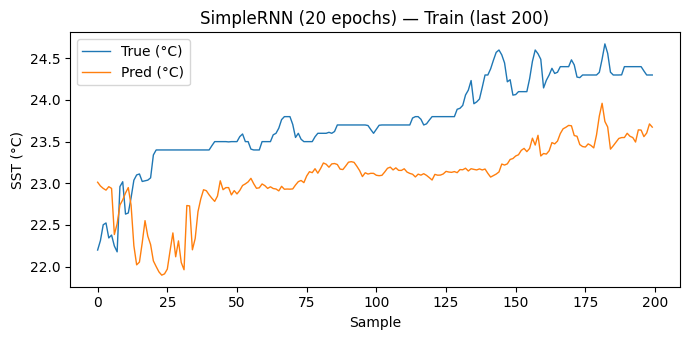


Saved: /content/drive/My Drive/Colab Notebooks/Validation_08/SimpleRNN_by_20epochs.csv
Done ✅ (DT_0008)


In [ ]:
from IPython.display import display
# ==== SimpleRNN — DT_0008 (Ansan) : one-cell pipeline ====CEL 6
import os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dropout, Dense
from tensorflow.keras import layers, activations

# ----------------- CONFIG -----------------
data_name = 8         # DT_0008 (Ansan)
epochs    = 20
WINDOW    = 24

# Auto-unzip if needed
if not os.path.isdir("/content/DT_0008_extracted"):
    os.system('unzip -q "DT_0008.zip" -d "DT_0008_extracted"')

# Output dirs
drive_base = "/content/drive/My Drive/Colab Notebooks"
use_drive  = os.path.exists("/content/drive/My Drive")
root_out   = drive_base if use_drive else "/content/outputs"
models_dir = f"{root_out}/Models_0{data_name}"
plots_dir  = f"{root_out}/Plots_0{data_name}"
pred_dir   = f"{root_out}/Prediction_0{data_name}"
val_dir    = f"{root_out}/Validation_0{data_name}"
for d in [models_dir, plots_dir, pred_dir, val_dir]:
    os.makedirs(d, exist_ok=True)

# ----------------- LOADERS (dup-safe) -----------------
def _load_json_hourly(path, keep_cols):
    with open(path, "r") as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    if "record_time" not in df.columns:
        raise ValueError(f"'record_time' missing in {path}")
    df["record_time"] = pd.to_datetime(df["record_time"])
    for c in keep_cols:
        if c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")
    cols = ["record_time"] + [c for c in keep_cols if c in df.columns]
    df = df[cols].set_index("record_time").sort_index().resample("h").mean()
    return df

def _collapse_features(df):
    base = ['sst','air_pres','water_temp','wind_dir','wind_speed']
    df = df.copy(); df.columns = [str(c) for c in df.columns]
    out = {}
    for name in base:
        pick = [c for c in df.columns if (c == name) or c.startswith(name)]
        if pick: out[name] = df[pick].astype(float).mean(axis=1)
    out_df = pd.DataFrame(out, index=df.index).sort_index()
    out_df = out_df[[c for c in base if c in out_df.columns]]
    assert out_df.columns.is_unique
    return out_df

def load_dt0008():
    base = "/content/DT_0008_extracted/DT_0008"
    if not os.path.isdir(base):
        raise FileNotFoundError(f"Not found: {base}")
    def load_folder(sub, keep):
        folder = os.path.join(base, sub)
        if not os.path.isdir(folder): return None
        frames = []
        for i, fname in enumerate(sorted(os.listdir(folder))):
            if fname.endswith(".json"):
                d = _load_json_hourly(os.path.join(folder, fname), keep)
                d.columns = [f"{c}_{sub}_{i}" for c in d.columns]  # unique suffix per file
                frames.append(d)
        if not frames: return None
        return pd.concat(frames, axis=1).sort_index()
    pieces = [
        load_folder("air_temp",     ["air_temp"]),
        load_folder("air_pres",     ["air_pres"]),
        load_folder("water_temp",   ["water_temp"]),
        load_folder("wind_dir_spd", ["wind_dir","wind_speed"]),
    ]
    pieces = [p for p in pieces if p is not None]
    if not pieces: raise RuntimeError("No JSON files for DT_0008.")
    raw = pd.concat(pieces, axis=1).sort_index()
    out_df = _collapse_features(raw).bfill().ffill()
    if 'water_temp' in out_df.columns and 'sst' not in out_df.columns:
        out_df = out_df.rename(columns={'water_temp': 'sst'})
    return out_df

# ---- Load
df = load_dt0008()
print("Loaded hourly table:", df.shape, "cols:", list(df.columns))
display(df.head())

# ---- Outlier fix
proc = df.copy()
for col in proc.columns:
    s = proc[col].astype(float)
    sd = s.std()
    if sd and not np.isnan(sd):
        mu = s.mean(); lo, hi = mu-3*sd, mu+3*sd
        mask = (s < lo) | (s > hi)
        if np.any(mask.to_numpy()):
            s[mask] = np.nan; s = s.bfill()
    proc[col] = s
proc = proc.ffill()

# ---- Split, scale
N = len(proc); split = int(N*0.85)
train_df, test_df = proc.iloc[:split], proc.iloc[split:]
scaler_all = MinMaxScaler()
train_scaled = scaler_all.fit_transform(train_df.values)
test_scaled  = scaler_all.transform(test_df.values)
sst_idx = train_df.columns.get_loc("sst")
sst_scaler = MinMaxScaler().fit(train_df.values[:, [sst_idx]])

# ---- Windows
def make_sup(arr, window=24, target_idx=2):
    X, y = [], []
    for i in range(window, len(arr)):
        X.append(arr[i-window:i, :]); y.append(arr[i, target_idx])
    return np.array(X), np.array(y)
X_tr, y_tr = make_sup(train_scaled, WINDOW, sst_idx)
X_te, y_te = make_sup(np.vstack([train_scaled[-WINDOW:], test_scaled]), WINDOW, sst_idx)
print("X_tr:", X_tr.shape, "y_tr:", y_tr.shape, "| X_te:", X_te.shape, "y_te:", y_te.shape)

# ---- SimpleRNN
model = Sequential([
    SimpleRNN(128, return_sequences=True, input_shape=(X_tr.shape[1], X_tr.shape[2])),
    Dropout(0.5),
    layers.Activation(activations.relu),
    SimpleRNN(128),
    Dropout(0.5),
    Dense(1)
])
model.compile(optimizer="adam",
              loss="mse",
              metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse"), "mae"])
history = model.fit(X_tr, y_tr, batch_size=32, epochs=epochs, verbose=1)
# after: history = model.fit(...)
rnn_model = model  # keep a handle to the RNN

# ---- Predict
yhat_tr = model.predict(X_tr, verbose=0).ravel()
yhat_te = model.predict(X_te, verbose=0).ravel()

# ---- Metrics
mae_tr_s = float(mean_absolute_error(y_tr, yhat_tr))
mae_te_s = float(mean_absolute_error(y_te, yhat_te))
rmse_tr_s = float(np.sqrt(mean_squared_error(y_tr, yhat_tr)))
rmse_te_s = float(np.sqrt(mean_squared_error(y_te, yhat_te)))
mse_tr_s  = float(mean_squared_error(y_tr, yhat_tr))
mse_te_s  = float(mean_squared_error(y_te, yhat_te))
y_tr_C    = sst_scaler.inverse_transform(y_tr.reshape(-1,1)).ravel()
y_te_C    = sst_scaler.inverse_transform(y_te.reshape(-1,1)).ravel()
yhat_tr_C = sst_scaler.inverse_transform(yhat_tr.reshape(-1,1)).ravel()
yhat_te_C = sst_scaler.inverse_transform(yhat_te.reshape(-1,1)).ravel()
mae_tr_C  = float(mean_absolute_error(y_tr_C, yhat_tr_C))
mae_te_C  = float(mean_absolute_error(y_te_C, yhat_te_C))
rmse_tr_C = float(np.sqrt(mean_squared_error(y_tr_C, yhat_tr_C)))
rmse_te_C = float(np.sqrt(mean_squared_error(y_te_C, yhat_te_C)))
mse_tr_C  = float(mean_squared_error(y_tr_C, yhat_tr_C))
mse_te_C  = float(mean_squared_error(y_te_C, yhat_te_C))
print(f"[SCALED] Train MAE={mae_tr_s:.6f} RMSE={rmse_tr_s:.6f} | Test MAE={mae_te_s:.6f} RMSE={rmse_te_s:.6f}")
print(f"[°C]     Train MAE={mae_tr_C:.4f} RMSE={rmse_tr_C:.4f} | Test MAE={mae_te_C:.4f} RMSE={rmse_te_C:.4f}")

# ---- Save CSVs, plots, model
val_path = f"{val_dir}/SimpleRNN_by_{epochs}epochs.csv"
pd.DataFrame({
    "MAE_train_scaled":[mae_tr_s], "RMSE_train_scaled":[rmse_tr_s],
    "MAE_test_scaled":[mae_te_s],  "RMSE_test_scaled":[rmse_te_s],
    "MAE_train_C":[mae_tr_C],      "RMSE_train_C":[rmse_tr_C],
    "MAE_test_C":[mae_te_C],       "RMSE_test_C":[rmse_te_C],
}).to_csv(val_path, index=False)

pd.DataFrame({
    "y_train_scaled": y_tr, "y_pred_train_scaled": yhat_tr,
    "y_train_C": y_tr_C,    "y_pred_train_C": yhat_tr_C
}).to_csv(f"{pred_dir}/SimpleRNN_by_{epochs}epochs_train.csv", index=False)

pd.DataFrame({
    "y_test_scaled": y_te, "y_pred_test_scaled": yhat_te,
    "y_test_C": y_te_C,    "y_pred_test_C": yhat_te_C
}).to_csv(f"{pred_dir}/SimpleRNN_by_{epochs}epochs_test.csv", index=False)

plt.figure(figsize=(7,3.5))
plt.plot(y_te_C[-200:], label="True (°C)", linewidth=1)
plt.plot(yhat_te_C[-200:], label="Pred (°C)", linewidth=1)
plt.title(f"SimpleRNN ({epochs} epochs) — Test (last 200)")
plt.xlabel("Sample"); plt.ylabel("SST (°C)"); plt.legend(); plt.tight_layout()
plt.savefig(f"{plots_dir}/SimpleRNN_by_{epochs}epochs_test.tiff", dpi=300); plt.show()

plt.figure(figsize=(7,3.5))
plt.plot(y_tr_C[-200:], label="True (°C)", linewidth=1)
plt.plot(yhat_tr_C[-200:], label="Pred (°C)", linewidth=1)
plt.title(f"SimpleRNN ({epochs} epochs) — Train (last 200)")
plt.xlabel("Sample"); plt.ylabel("SST (°C)"); plt.legend(); plt.tight_layout()
plt.savefig(f"{plots_dir}/SimpleRNN_by_{epochs}epochs_train.tiff", dpi=300); plt.show()

model.save(f"{models_dir}/SimpleRNN_by_{epochs}epochs.h5")
print("\nSaved:", val_path)
print("Done ✅ (DT_0008)")


Loaded hourly table: (89833, 5) cols: ['air_temp', 'air_pres', 'water_temp', 'wind_dir', 'wind_speed']


,air_temp,air_pres,water_temp,wind_dir,wind_speed
record_time,,,,,
2012-01-01 00:00:00,0.288333,1027.126667,1.800000,148.233333,1.008333
2012-01-01 01:00:00,-0.010000,1026.815000,1.800000,99.550000,0.656667
2012-01-01 02:00:00,-0.888333,1026.678333,1.800000,73.416667,1.016667
2012-01-01 03:00:00,-1.071186,1026.623729,1.800000,67.389831,0.925424
2012-01-01 04:00:00,-1.788333,1026.518333,1.886667,68.350000,0.570000


X_tr: (76334, 24, 5) y_tr: (76334,) | X_te: (13475, 24, 5) y_te: (13475,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 180s 74ms/step - loss: 0.0652 - mae: 0.0497
Epoch 2/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 178s 75ms/step - loss: 0.0313 - mae: 0.0234
Epoch 3/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 178s 75ms/step - loss: 0.0290 - mae: 0.0218
Epoch 4/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 196s 72ms/step - loss: 0.0276 - mae: 0.0208
Epoch 5/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 199s 71ms/step - loss: 0.0274 - mae: 0.0206
Epoch 6/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 201s 71ms/step - loss: 0.0271 - mae: 0.0204
Epoch 7/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 207s 73ms/step - loss: 0.0263 - mae: 0.0198
Epoch 8/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 174s 73ms/step - loss: 0.0261 - mae: 0.0197
Epoch 9/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 174s 73ms/step - loss: 0.0258 - mae: 0.0195
Epoch 10/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 176s 74ms/step - loss: 0.0257 - mae: 0.0193
Epoch 11/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 202s 74ms/step - loss: 0.0255 - mae: 0.0191
Epoch 12/20
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 172s 72ms

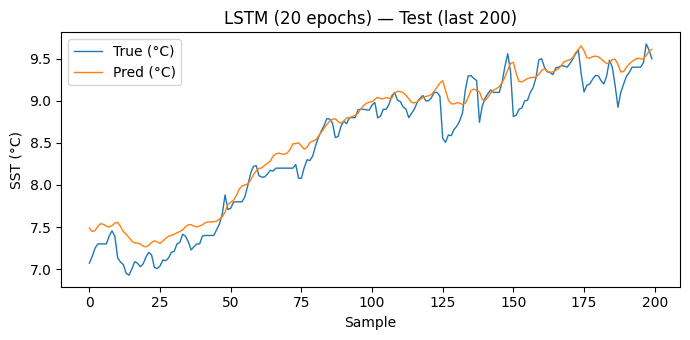

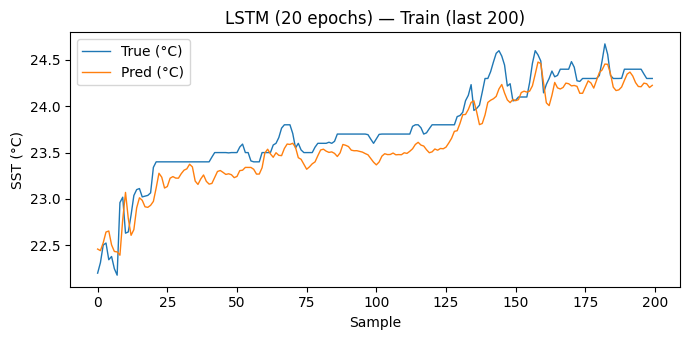


Saved to:
- /content/drive/My Drive/Colab Notebooks/Validation_08/LSTM_by_20epochs.csv
- /content/drive/My Drive/Colab Notebooks/Prediction_08/LSTM_by_20epochs_[train|test].csv
- /content/drive/My Drive/Colab Notebooks/Plots_08/LSTM_by_20epochs_[train|test].tiff
- /content/drive/My Drive/Colab Notebooks/Models_08/LSTM_by_20epochs.h5

Done ✅


In [ ]:
from IPython.display import display
#cell 7
import os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras import layers, activations
from keras import backend as K

# ----------------- CONFIG -----------------
data_name = 8         # 1 = DT_0001 (Incheon), 8 = DT_0008 (Ansan)
epochs    = 20
WINDOW    = 24

# Output dirs: prefer Drive if mounted, else local /content/outputs
drive_base = "/content/drive/My Drive/Colab Notebooks"
use_drive  = os.path.exists("/content/drive/My Drive")
root_out   = drive_base if use_drive else "/content/outputs"
models_dir = f"{root_out}/Models_0{data_name}"
plots_dir  = f"{root_out}/Plots_0{data_name}"
pred_dir   = f"{root_out}/Prediction_0{data_name}"
val_dir    = f"{root_out}/Validation_0{data_name}"
for d in [models_dir, plots_dir, pred_dir, val_dir]:
    os.makedirs(d, exist_ok=True)

# ----------------- LOADERS -----------------
# ----------------- LOADERS (dup-safe, unique columns, robust) -----------------
def _load_json_hourly(path, keep_cols):
    import json, pandas as pd
    with open(path, "r") as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    if "record_time" not in df.columns:
        raise ValueError(f"'record_time' missing in {path}")
    df["record_time"] = pd.to_datetime(df["record_time"])
    for c in keep_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    cols = ["record_time"] + [c for c in keep_cols if c in df.columns]
    df = df[cols].set_index("record_time").sort_index().resample("h").mean()
    return df

def _collapse_features(df):
    """
    Collapse duplicate or variant columns into exactly these 5 unique columns:
    ['air_temp','air_pres','water_temp','wind_dir','wind_speed'] by averaging.
    """
    base = ['sst','air_pres','water_temp','wind_dir','wind_speed']
    # normalize column names to strings
    df = df.copy()
    df.columns = [str(c) for c in df.columns]
    out = {}
    for name in base:
        pick = [c for c in df.columns if (c == name) or c.startswith(name)]
        if pick:
            out[name] = df[pick].astype(float).mean(axis=1)
    if not out:
        raise RuntimeError("No expected feature columns found to collapse.")
    out_df = pd.DataFrame(out, index=df.index).sort_index()
    # assure order and uniqueness
    ordered = [c for c in base if c in out_df.columns]
    out_df = out_df[ordered]
    assert out_df.columns.is_unique, "Collapsed columns are still not unique."
    return out_df

def load_dt0001():
    base = "/content/DT_0001_extracted/MultiFeature_DT_0001"
    if not os.path.isdir(base):
        raise FileNotFoundError(f"Not found: {base} (unzip DT_0001.zip first)")
    pieces = []
    for year in sorted(os.listdir(base)):
        ypath = os.path.join(base, year)
        if not os.path.isdir(ypath):
            continue
        yy = str(year)[-2:]  # e.g., '12'
        spec = [
            (f"air_temp{yy}.json",     ["air_temp"]),
            (f"air_pres{yy}.json",     ["air_pres"]),
            (f"water_temp{yy}.json",   ["water_temp"]),
            (f"wind_dir_spd{yy}.json", ["wind_dir","wind_speed"]),
        ]
        for fname, keep in spec:
            p = os.path.join(ypath, fname)
            if os.path.exists(p):
                d = _load_json_hourly(p, keep)
                # give each column a unique suffix from the year, so no collisions
                d.columns = [f"{c}_{yy}" for c in d.columns]
                pieces.append(d)
    if not pieces:
        raise RuntimeError("No JSON files loaded for DT_0001.")
    raw = pd.concat(pieces, axis=1).sort_index()
    df = _collapse_features(raw).bfill().ffill()
    return df

def load_dt0008():
    base = "/content/DT_0008_extracted/DT_0008"
    if not os.path.isdir(base):
        raise FileNotFoundError(f"Not found: {base} (unzip DT_0008.zip first)")
    def load_folder(sub, keep):
        folder = os.path.join(base, sub)
        if not os.path.isdir(folder):
            return None
        frames = []
        # enumerate files so we can suffix with a unique index per file
        for i, fname in enumerate(sorted(os.listdir(folder))):
            if fname.endswith(".json"):
                d = _load_json_hourly(os.path.join(folder, fname), keep)
                d.columns = [f"{c}_{sub}_{i}" for c in d.columns]  # unique per file
                frames.append(d)
        if not frames:
            return None
        return pd.concat(frames, axis=1).sort_index()

    pieces = [
        load_folder("air_temp",     ["air_temp"]),
        load_folder("air_pres",     ["air_pres"]),
        load_folder("water_temp",   ["water_temp"]),
        load_folder("wind_dir_spd", ["wind_dir","wind_speed"]),
    ]
    pieces = [p for p in pieces if p is not None]
    if not pieces:
        raise RuntimeError("No JSON files loaded for DT_0008.")
    raw = pd.concat(pieces, axis=1).sort_index()
    df = _collapse_features(raw).bfill().ffill()
    return df

# ---- Choose dataset (set data_name=8 for DT_0008)
df = load_dt0001() if data_name == 1 else load_dt0008()
print("Loaded hourly table:", df.shape, "cols:", list(df.columns))
display(df.head())








# ----------------- OUTLIER FIX -----------------
proc = df.copy()
for col in proc.columns:
    s = proc[col].astype(float)
    sd = s.std()
    if sd == 0 or np.isnan(sd):  # nothing to clip
        continue
    mu = s.mean()
    lo, hi = mu - 3*sd, mu + 3*sd
    mask = (s < lo) | (s > hi)
    if np.any(mask.to_numpy()):
        s[mask] = np.nan
        s = s.bfill()
    proc[col] = s
proc = proc.ffill()

# ----------------- TRAIN/TEST SPLIT (chronological) -----------------
N = len(proc)
split = int(N*0.85)
train_df = proc.iloc[:split].copy()
test_df  = proc.iloc[split:].copy()

# ----------------- SCALING (fit on TRAIN only) -----------------
scaler_all = MinMaxScaler()
train_scaled = scaler_all.fit_transform(train_df.values)
test_scaled  = scaler_all.transform(test_df.values)

# target index (SST)
sst_idx = train_df.columns.get_loc("sst")
sst_scaler = MinMaxScaler()
sst_scaler.fit(train_df.values[:, [sst_idx]])

# ----------------- MAKE SLIDING WINDOWS -----------------
def make_sup(arr, window=24, target_idx=2):
    X, y = [], []
    for i in range(window, len(arr)):
        X.append(arr[i-window:i, :])
        y.append(arr[i, target_idx])
    return np.array(X), np.array(y)

X_tr, y_tr = make_sup(train_scaled, WINDOW, sst_idx)
# ensure context continuity into test by prepending last WINDOW rows of train
X_te, y_te = make_sup(np.vstack([train_scaled[-WINDOW:], test_scaled]), WINDOW, sst_idx)

print("X_tr:", X_tr.shape, "y_tr:", y_tr.shape, "| X_te:", X_te.shape, "y_te:", y_te.shape)

# ----------------- BUILD & TRAIN MODEL -----------------
import tensorflow as tf

def rmse_loss(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_true)))


model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_tr.shape[1], X_tr.shape[2])),
    Dropout(0.5),
    layers.Activation(activations.relu),
    LSTM(128),
    Dropout(0.5),
    Dense(1)
])
model.compile(optimizer="adam", loss=rmse_loss, metrics=["mae"])

hist = model.fit(X_tr, y_tr, batch_size=32, epochs=epochs, verbose=1)
# after: hist = model.fit(...)
lstm_model = model  # keep a handle to the LSTM before you redefine `model` later

# ----------------- PREDICT -----------------
y_pred_tr = model.predict(X_tr, verbose=0).ravel()
y_pred_te = model.predict(X_te, verbose=0).ravel()

# ----------------- METRICS (scaled & °C) -----------------
mae_tr_s = float(mean_absolute_error(y_tr, y_pred_tr))
mae_te_s = float(mean_absolute_error(y_te, y_pred_te))
rmse_tr_s = float(np.sqrt(mean_squared_error(y_tr, y_pred_tr)))
rmse_te_s = float(np.sqrt(mean_squared_error(y_te, y_pred_te)))

y_tr_C   = sst_scaler.inverse_transform(y_tr.reshape(-1,1)).ravel()
y_te_C   = sst_scaler.inverse_transform(y_te.reshape(-1,1)).ravel()
yhat_tr_C= sst_scaler.inverse_transform(y_pred_tr.reshape(-1,1)).ravel()
yhat_te_C= sst_scaler.inverse_transform(y_pred_te.reshape(-1,1)).ravel()

mae_tr_C = float(mean_absolute_error(y_tr_C, yhat_tr_C))
mae_te_C = float(mean_absolute_error(y_te_C, yhat_te_C))
rmse_tr_C= float(np.sqrt(mean_squared_error(y_tr_C, yhat_tr_C)))
rmse_te_C= float(np.sqrt(mean_squared_error(y_te_C, yhat_te_C)))

print(f"[SCALED]  Train MAE={mae_tr_s:.6f} RMSE={rmse_tr_s:.6f} | Test MAE={mae_te_s:.6f} RMSE={rmse_te_s:.6f}")
print(f"[°C]      Train MAE={mae_tr_C:.4f} RMSE={rmse_tr_C:.4f} | Test MAE={mae_te_C:.4f} RMSE={rmse_te_C:.4f}")

# ----------------- SAVE CSVs -----------------
val_path = f"{val_dir}/LSTM_by_{epochs}epochs.csv"
pd.DataFrame({
    "MAE_train_scaled":[mae_tr_s], "RMSE_train_scaled":[rmse_tr_s],
    "MAE_test_scaled":[mae_te_s],  "RMSE_test_scaled":[rmse_te_s],
    "MAE_train_C":[mae_tr_C],      "RMSE_train_C":[rmse_tr_C],
    "MAE_test_C":[mae_te_C],       "RMSE_test_C":[rmse_te_C],
}).to_csv(val_path, index=False)

pd.DataFrame({
    "y_train_scaled": y_tr, "y_pred_train_scaled": y_pred_tr,
    "y_train_C": y_tr_C,    "y_pred_train_C": yhat_tr_C
}).to_csv(f"{pred_dir}/LSTM_by_{epochs}epochs_train.csv", index=False)

pd.DataFrame({
    "y_test_scaled": y_te, "y_pred_test_scaled": y_pred_te,
    "y_test_C": y_te_C,    "y_pred_test_C": yhat_te_C
}).to_csv(f"{pred_dir}/LSTM_by_{epochs}epochs_test.csv", index=False)

# ----------------- PLOTS -----------------
plt.figure(figsize=(7,3.5))
plt.plot(y_te_C[-200:], label="True (°C)", linewidth=1)
plt.plot(yhat_te_C[-200:], label="Pred (°C)", linewidth=1)
plt.title(f"LSTM ({epochs} epochs) — Test (last 200)")
plt.xlabel("Sample"); plt.ylabel("SST (°C)"); plt.legend(); plt.tight_layout()
plt.savefig(f"{plots_dir}/LSTM_by_{epochs}epochs_test.tiff", dpi=300); plt.show()

plt.figure(figsize=(7,3.5))
plt.plot(y_tr_C[-200:], label="True (°C)", linewidth=1)
plt.plot(yhat_tr_C[-200:], label="Pred (°C)", linewidth=1)
plt.title(f"LSTM ({epochs} epochs) — Train (last 200)")
plt.xlabel("Sample"); plt.ylabel("SST (°C)"); plt.legend(); plt.tight_layout()
plt.savefig(f"{plots_dir}/LSTM_by_{epochs}epochs_train.tiff", dpi=300); plt.show()

# ----------------- SAVE MODEL -----------------
model.save(f"{models_dir}/LSTM_by_{epochs}epochs.h5")
print("\nSaved to:")
print("-", val_path)
print("-", f"{pred_dir}/LSTM_by_{epochs}epochs_[train|test].csv")
print("-", f"{plots_dir}/LSTM_by_{epochs}epochs_[train|test].tiff")
print("-", f"{models_dir}/LSTM_by_{epochs}epochs.h5")
print("\nDone ✅")


Loaded hourly table: (89723, 5) cols: ['air_temp', 'air_pres', 'water_temp', 'wind_dir', 'wind_speed']


,air_temp,air_pres,water_temp,wind_dir,wind_speed
record_time,,,,,
2012-01-01 00:00:00,0.076667,1022.790000,3.863333,96.666667,0.411667
2012-01-01 01:00:00,-0.178333,1022.490000,3.898333,46.600000,0.728333
2012-01-01 02:00:00,-0.551667,1022.336667,3.865000,8.233333,2.636667
2012-01-01 03:00:00,-0.701667,1022.340000,3.900000,30.166667,2.045000
2012-01-01 04:00:00,-0.880000,1022.133333,3.896667,8.666667,2.586667


X_tr: (76240, 24, 5) y_tr: (76240,) | X_te: (13459, 24, 5) y_te: (13459,)
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2383/2383 ━━━━━━━━━━━━━━━━━━━━ 196s 80ms/step - loss: 0.0618 - mae: 0.0472
Epoch 2/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 190s 80ms/step - loss: 0.0305 - mae: 0.0231
Epoch 3/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 203s 80ms/step - loss: 0.0287 - mae: 0.0219
Epoch 4/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 192s 81ms/step - loss: 0.0278 - mae: 0.0212
Epoch 5/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 201s 80ms/step - loss: 0.0270 - mae: 0.0206
Epoch 6/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 203s 81ms/step - loss: 0.0267 - mae: 0.0203
Epoch 7/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 191s 80ms/step - loss: 0.0264 - mae: 0.0200
Epoch 8/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 201s 80ms/step - loss: 0.0260 - mae: 0.0196
Epoch 9/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 202s 80ms/step - loss: 0.0261 - mae: 0.0198
Epoch 10/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 190s 80ms/step - loss: 0.0259 - mae: 0.0195
Epoch 11/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 190s 80ms/step - loss: 0.0259 - mae: 0.0195
Epoch 12/20
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 191s 80ms/step - los

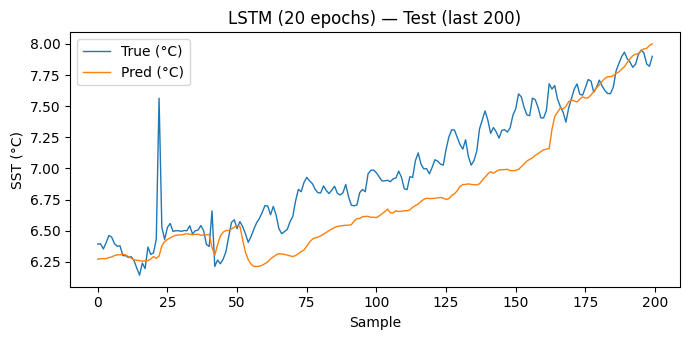

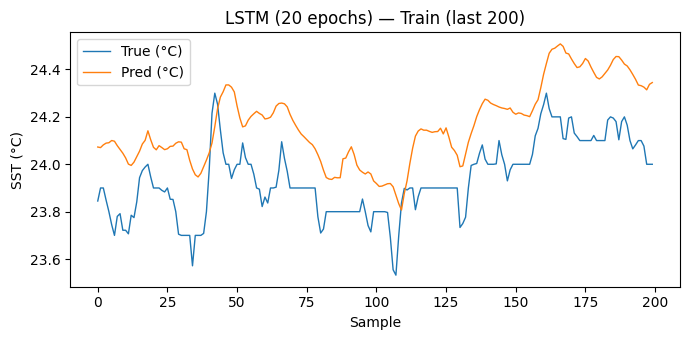


Saved to:
- /content/drive/My Drive/Colab Notebooks/Validation_01/LSTM_by_20epochs.csv
- /content/drive/My Drive/Colab Notebooks/Prediction_01/LSTM_by_20epochs_[train|test].csv
- /content/drive/My Drive/Colab Notebooks/Plots_01/LSTM_by_20epochs_[train|test].tiff
- /content/drive/My Drive/Colab Notebooks/Models_01/LSTM_by_20epochs.h5

Done ✅


In [ ]:
from IPython.display import display
# cell 8
import os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras import layers, activations
from keras import backend as K

# ----------------- CONFIG -----------------
data_name = 1         # 1 = DT_0001 (Incheon), 8 = DT_0008 (Ansan)
epochs    = 20
WINDOW    = 24

# Output dirs: prefer Drive if mounted, else local /content/outputs
drive_base = "/content/drive/My Drive/Colab Notebooks"
use_drive  = os.path.exists("/content/drive/My Drive")
root_out   = drive_base if use_drive else "/content/outputs"
models_dir = f"{root_out}/Models_0{data_name}"
plots_dir  = f"{root_out}/Plots_0{data_name}"
pred_dir   = f"{root_out}/Prediction_0{data_name}"
val_dir    = f"{root_out}/Validation_0{data_name}"
for d in [models_dir, plots_dir, pred_dir, val_dir]:
    os.makedirs(d, exist_ok=True)

# ----------------- LOADERS -----------------
# ----------------- LOADERS (dup-safe, unique columns, robust) -----------------
def _load_json_hourly(path, keep_cols):
    import json, pandas as pd
    with open(path, "r") as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    if "record_time" not in df.columns:
        raise ValueError(f"'record_time' missing in {path}")
    df["record_time"] = pd.to_datetime(df["record_time"])
    for c in keep_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    cols = ["record_time"] + [c for c in keep_cols if c in df.columns]
    df = df[cols].set_index("record_time").sort_index().resample("h").mean()
    return df

def _collapse_features(df):
    """
    Collapse duplicate or variant columns into exactly these 5 unique columns:
    ['air_temp','air_pres','water_temp','wind_dir','wind_speed'] by averaging.
    """
    base = ['sst','air_pres','water_temp','wind_dir','wind_speed']
    # normalize column names to strings
    df = df.copy()
    df.columns = [str(c) for c in df.columns]
    out = {}
    for name in base:
        pick = [c for c in df.columns if (c == name) or c.startswith(name)]
        if pick:
            out[name] = df[pick].astype(float).mean(axis=1)
    if not out:
        raise RuntimeError("No expected feature columns found to collapse.")
    out_df = pd.DataFrame(out, index=df.index).sort_index()
    # assure order and uniqueness
    ordered = [c for c in base if c in out_df.columns]
    out_df = out_df[ordered]
    assert out_df.columns.is_unique, "Collapsed columns are still not unique."
    return out_df

def load_dt0001():
    base = "/content/DT_0001_extracted/MultiFeature_DT_0001"
    if not os.path.isdir(base):
        raise FileNotFoundError(f"Not found: {base} (unzip DT_0001.zip first)")
    pieces = []
    for year in sorted(os.listdir(base)):
        ypath = os.path.join(base, year)
        if not os.path.isdir(ypath):
            continue
        yy = str(year)[-2:]  # e.g., '12'
        spec = [
            (f"air_temp{yy}.json",     ["air_temp"]),
            (f"air_pres{yy}.json",     ["air_pres"]),
            (f"water_temp{yy}.json",   ["water_temp"]),
            (f"wind_dir_spd{yy}.json", ["wind_dir","wind_speed"]),
        ]
        for fname, keep in spec:
            p = os.path.join(ypath, fname)
            if os.path.exists(p):
                d = _load_json_hourly(p, keep)
                # give each column a unique suffix from the year, so no collisions
                d.columns = [f"{c}_{yy}" for c in d.columns]
                pieces.append(d)
    if not pieces:
        raise RuntimeError("No JSON files loaded for DT_0001.")
    raw = pd.concat(pieces, axis=1).sort_index()
    df = _collapse_features(raw).bfill().ffill()
    return df

def load_dt0008():
    base = "/content/DT_0008_extracted/DT_0008"
    if not os.path.isdir(base):
        raise FileNotFoundError(f"Not found: {base} (unzip DT_0008.zip first)")
    def load_folder(sub, keep):
        folder = os.path.join(base, sub)
        if not os.path.isdir(folder):
            return None
        frames = []
        # enumerate files so we can suffix with a unique index per file
        for i, fname in enumerate(sorted(os.listdir(folder))):
            if fname.endswith(".json"):
                d = _load_json_hourly(os.path.join(folder, fname), keep)
                d.columns = [f"{c}_{sub}_{i}" for c in d.columns]  # unique per file
                frames.append(d)
        if not frames:
            return None
        return pd.concat(frames, axis=1).sort_index()

    pieces = [
        load_folder("air_temp",     ["air_temp"]),
        load_folder("air_pres",     ["air_pres"]),
        load_folder("water_temp",   ["water_temp"]),
        load_folder("wind_dir_spd", ["wind_dir","wind_speed"]),
    ]
    pieces = [p for p in pieces if p is not None]
    if not pieces:
        raise RuntimeError("No JSON files loaded for DT_0008.")
    raw = pd.concat(pieces, axis=1).sort_index()
    df = _collapse_features(raw).bfill().ffill()
    return df

# ---- Choose dataset (set data_name=8 for DT_0008)
df = load_dt0001() if data_name == 1 else load_dt0008()
print("Loaded hourly table:", df.shape, "cols:", list(df.columns))
display(df.head())








# ----------------- OUTLIER FIX -----------------
proc = df.copy()
for col in proc.columns:
    s = proc[col].astype(float)
    sd = s.std()
    if sd == 0 or np.isnan(sd):  # nothing to clip
        continue
    mu = s.mean()
    lo, hi = mu - 3*sd, mu + 3*sd
    mask = (s < lo) | (s > hi)
    if np.any(mask.to_numpy()):
        s[mask] = np.nan
        s = s.bfill()
    proc[col] = s
proc = proc.ffill()

# ----------------- TRAIN/TEST SPLIT (chronological) -----------------
N = len(proc)
split = int(N*0.85)
train_df = proc.iloc[:split].copy()
test_df  = proc.iloc[split:].copy()

# ----------------- SCALING (fit on TRAIN only) -----------------
scaler_all = MinMaxScaler()
train_scaled = scaler_all.fit_transform(train_df.values)
test_scaled  = scaler_all.transform(test_df.values)

# target index (SST)
sst_idx = train_df.columns.get_loc("sst")
sst_scaler = MinMaxScaler()
sst_scaler.fit(train_df.values[:, [sst_idx]])

# ----------------- MAKE SLIDING WINDOWS -----------------
def make_sup(arr, window=24, target_idx=2):
    X, y = [], []
    for i in range(window, len(arr)):
        X.append(arr[i-window:i, :])
        y.append(arr[i, target_idx])
    return np.array(X), np.array(y)

X_tr, y_tr = make_sup(train_scaled, WINDOW, sst_idx)
# ensure context continuity into test by prepending last WINDOW rows of train
X_te, y_te = make_sup(np.vstack([train_scaled[-WINDOW:], test_scaled]), WINDOW, sst_idx)

print("X_tr:", X_tr.shape, "y_tr:", y_tr.shape, "| X_te:", X_te.shape, "y_te:", y_te.shape)
cnn_lstm_model = Sequential([
    # CNN part
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(X_tr.shape[1], X_tr.shape[2])),
    MaxPooling1D(pool_size=2),

    # LSTM part
    LSTM(64),
    Dropout(0.5),

    # Output
    Dense(1)
])

cnn_lstm_model.compile(optimizer="adam", loss=rmse_loss, metrics=["mae"])
cnn_lstm_model.summary()
# ----------------- BUILD & TRAIN MODEL -----------------
import tensorflow as tf

def rmse_loss(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_true)))


model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_tr.shape[1], X_tr.shape[2])),
    Dropout(0.5),
    layers.Activation(activations.relu),
    LSTM(128),
    Dropout(0.5),
    Dense(1)
])
model.compile(optimizer="adam", loss=rmse_loss, metrics=["mae"])

hist = model.fit(X_tr, y_tr, batch_size=32, epochs=epochs, verbose=1)
# after: hist = model.fit(...)
lstm_model = model  # keep a handle to the LSTM before you redefine `model` later

# ----------------- PREDICT -----------------
y_pred_tr = model.predict(X_tr, verbose=0).ravel()
y_pred_te = model.predict(X_te, verbose=0).ravel()

# ----------------- METRICS (scaled & °C) -----------------
mae_tr_s = float(mean_absolute_error(y_tr, y_pred_tr))
mae_te_s = float(mean_absolute_error(y_te, y_pred_te))
rmse_tr_s = float(np.sqrt(mean_squared_error(y_tr, y_pred_tr)))
rmse_te_s = float(np.sqrt(mean_squared_error(y_te, y_pred_te)))

y_tr_C   = sst_scaler.inverse_transform(y_tr.reshape(-1,1)).ravel()
y_te_C   = sst_scaler.inverse_transform(y_te.reshape(-1,1)).ravel()
yhat_tr_C= sst_scaler.inverse_transform(y_pred_tr.reshape(-1,1)).ravel()
yhat_te_C= sst_scaler.inverse_transform(y_pred_te.reshape(-1,1)).ravel()

mae_tr_C = float(mean_absolute_error(y_tr_C, yhat_tr_C))
mae_te_C = float(mean_absolute_error(y_te_C, yhat_te_C))
rmse_tr_C= float(np.sqrt(mean_squared_error(y_tr_C, yhat_tr_C)))
rmse_te_C= float(np.sqrt(mean_squared_error(y_te_C, yhat_te_C)))

print(f"[SCALED]  Train MAE={mae_tr_s:.6f} RMSE={rmse_tr_s:.6f} | Test MAE={mae_te_s:.6f} RMSE={rmse_te_s:.6f}")
print(f"[°C]      Train MAE={mae_tr_C:.4f} RMSE={rmse_tr_C:.4f} | Test MAE={mae_te_C:.4f} RMSE={rmse_te_C:.4f}")

# ----------------- SAVE CSVs -----------------
val_path = f"{val_dir}/LSTM_by_{epochs}epochs.csv"
pd.DataFrame({
    "MAE_train_scaled":[mae_tr_s], "RMSE_train_scaled":[rmse_tr_s],
    "MAE_test_scaled":[mae_te_s],  "RMSE_test_scaled":[rmse_te_s],
    "MAE_train_C":[mae_tr_C],      "RMSE_train_C":[rmse_tr_C],
    "MAE_test_C":[mae_te_C],       "RMSE_test_C":[rmse_te_C],
}).to_csv(val_path, index=False)

pd.DataFrame({
    "y_train_scaled": y_tr, "y_pred_train_scaled": y_pred_tr,
    "y_train_C": y_tr_C,    "y_pred_train_C": yhat_tr_C
}).to_csv(f"{pred_dir}/LSTM_by_{epochs}epochs_train.csv", index=False)

pd.DataFrame({
    "y_test_scaled": y_te, "y_pred_test_scaled": y_pred_te,
    "y_test_C": y_te_C,    "y_pred_test_C": yhat_te_C
}).to_csv(f"{pred_dir}/LSTM_by_{epochs}epochs_test.csv", index=False)

# ----------------- PLOTS -----------------
plt.figure(figsize=(7,3.5))
plt.plot(y_te_C[-200:], label="True (°C)", linewidth=1)
plt.plot(yhat_te_C[-200:], label="Pred (°C)", linewidth=1)
plt.title(f"LSTM ({epochs} epochs) — Test (last 200)")
plt.xlabel("Sample"); plt.ylabel("SST (°C)"); plt.legend(); plt.tight_layout()
plt.savefig(f"{plots_dir}/LSTM_by_{epochs}epochs_test.tiff", dpi=300); plt.show()

plt.figure(figsize=(7,3.5))
plt.plot(y_tr_C[-200:], label="True (°C)", linewidth=1)
plt.plot(yhat_tr_C[-200:], label="Pred (°C)", linewidth=1)
plt.title(f"LSTM ({epochs} epochs) — Train (last 200)")
plt.xlabel("Sample"); plt.ylabel("SST (°C)"); plt.legend(); plt.tight_layout()
plt.savefig(f"{plots_dir}/LSTM_by_{epochs}epochs_train.tiff", dpi=300); plt.show()

# ----------------- SAVE MODEL -----------------
model.save(f"{models_dir}/LSTM_by_{epochs}epochs.h5")
print("\nSaved to:")
print("-", val_path)
print("-", f"{pred_dir}/LSTM_by_{epochs}epochs_[train|test].csv")
print("-", f"{plots_dir}/LSTM_by_{epochs}epochs_[train|test].tiff")
print("-", f"{models_dir}/LSTM_by_{epochs}epochs.h5")
print("\nDone ✅")


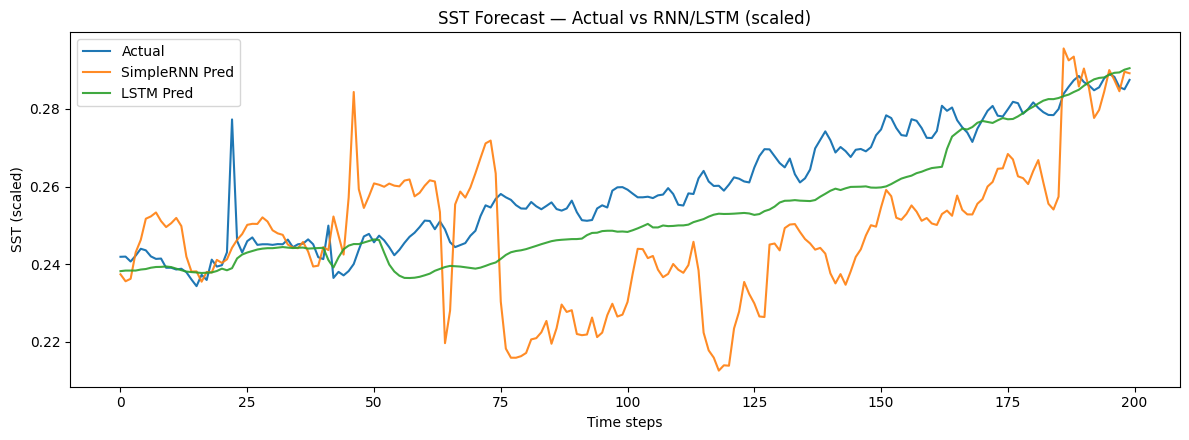

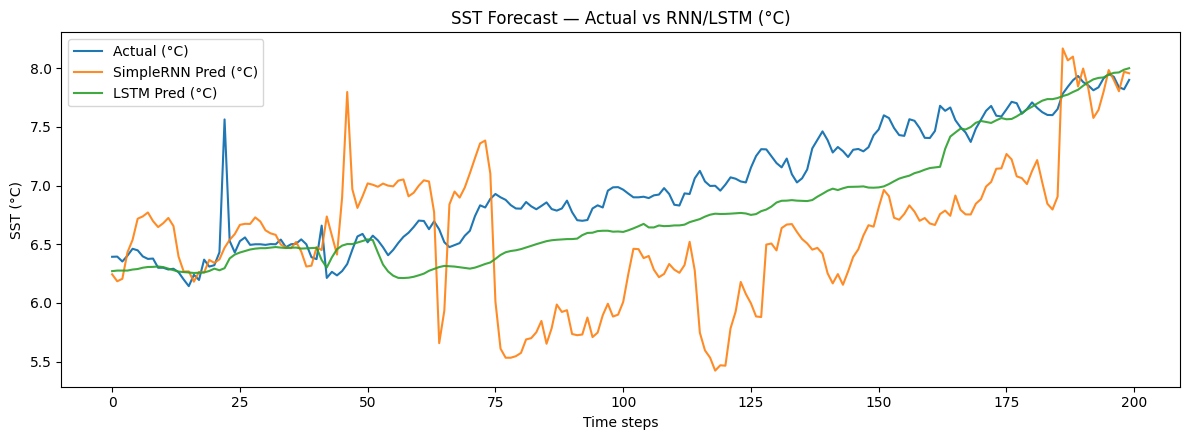


== Test comparison (scaled) ==


,Model,MAE_scaled,MSE_scaled,RMSE_scaled
0,SimpleRNN,0.015212,0.000634,0.025185
1,LSTM,0.004679,0.000093,0.009621



== Test comparison (°C) ==


,Model,MAE_C,MSE_C,RMSE_C
0,SimpleRNN,0.5028,0.6928,0.8324
1,LSTM,0.1546,0.1011,0.3180


In [ ]:
from IPython.display import display
#cell 9:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

def eval_regression(model, X_test, y_test):
    pred = model.predict(X_test, verbose=0).reshape(-1)
    true = np.array(y_test).reshape(-1)
    mae  = mean_absolute_error(true, pred)
    mse  = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    return mae, mse, rmse, pred, true

def overlay_compare_scaled(rnn_model, lstm_model, X_test, y_test, n_points=200, title_suffix="(scaled)"):
    # RNN
    mae_rnn, mse_rnn, rmse_rnn, pred_rnn, true_s = eval_regression(rnn_model, X_test, y_test)
    # LSTM
    mae_lstm, mse_lstm, rmse_lstm, pred_lstm, _ = eval_regression(lstm_model, X_test, y_test)

    # Slice last n points
    if 0 < n_points < len(true_s):
        sl = slice(-n_points, None)
    else:
        sl = slice(None)

    plt.figure(figsize=(12, 4.5))
    plt.plot(true_s[sl],       label="Actual", linewidth=1.5)
    plt.plot(pred_rnn[sl],     label="SimpleRNN Pred", alpha=0.9)
    plt.plot(pred_lstm[sl],    label="LSTM Pred", alpha=0.9)
    plt.title(f"SST Forecast — Actual vs RNN/LSTM {title_suffix}")
    plt.xlabel("Time steps"); plt.ylabel("SST (scaled)"); plt.legend()
    plt.tight_layout(); plt.show()

    rows = [
        {"Model":"SimpleRNN","MAE_scaled":mae_rnn,"MSE_scaled":mse_rnn,"RMSE_scaled":rmse_rnn},
        {"Model":"LSTM",     "MAE_scaled":mae_lstm,"MSE_scaled":mse_lstm,"RMSE_scaled":rmse_lstm},
    ]
    return pd.DataFrame(rows)

def inverse_transform_sst(scaler, sst_scaled_vector):
    s = np.asarray(sst_scaled_vector).reshape(-1, 1)
    # scaler was fit on SST-only in your code for sst_scaler, so we can invert directly:
    return scaler.inverse_transform(s).ravel()

def overlay_compare_C(rnn_model, lstm_model, X_test, y_test, sst_scaler, n_points=200):
    # Scaled eval
    _, _, _, pred_rnn_s, true_s = eval_regression(rnn_model, X_test, y_test)
    _, _, _, pred_lstm_s, _     = eval_regression(lstm_model, X_test, y_test)

    # Inverse to °C using your sst_scaler (fit on SST-only)
    true_C      = inverse_transform_sst(sst_scaler, true_s)
    pred_rnn_C  = inverse_transform_sst(sst_scaler, pred_rnn_s)
    pred_lstm_C = inverse_transform_sst(sst_scaler, pred_lstm_s)

    mae_rnn = mean_absolute_error(true_C, pred_rnn_C)
    mse_rnn = mean_squared_error(true_C, pred_rnn_C); rmse_rnn = np.sqrt(mse_rnn)
    mae_lstm = mean_absolute_error(true_C, pred_lstm_C)
    mse_lstm = mean_squared_error(true_C, pred_lstm_C); rmse_lstm = np.sqrt(mse_lstm)

    # Slice
    if 0 < n_points < len(true_C):
        sl = slice(-n_points, None)
    else:
        sl = slice(None)

    plt.figure(figsize=(12, 4.5))
    plt.plot(true_C[sl],      label="Actual (°C)", linewidth=1.5)
    plt.plot(pred_rnn_C[sl],  label="SimpleRNN Pred (°C)", alpha=0.9)
    plt.plot(pred_lstm_C[sl], label="LSTM Pred (°C)", alpha=0.9)
    plt.title("SST Forecast — Actual vs RNN/LSTM (°C)")
    plt.xlabel("Time steps"); plt.ylabel("SST (°C)"); plt.legend()
    plt.tight_layout(); plt.show()

    rows = [
        {"Model":"SimpleRNN","MAE_C":mae_rnn,"MSE_C":mse_rnn,"RMSE_C":rmse_rnn},
        {"Model":"LSTM",     "MAE_C":mae_lstm,"MSE_C":mse_lstm,"RMSE_C":rmse_lstm},
    ]
    return pd.DataFrame(rows)

# ===== Run comparisons (needs: rnn_model, lstm_model, X_te, y_te, sst_scaler) =====
df_scaled = overlay_compare_scaled(rnn_model, lstm_model, X_te, y_te, n_points=200)
df_C      = overlay_compare_C(rnn_model, lstm_model, X_te, y_te, sst_scaler, n_points=200)

print("\n== Test comparison (scaled) ==")
display(df_scaled.round(6))
print("\n== Test comparison (°C) ==")
display(df_C.round(4))


In [ ]:
cmp = df_scaled.merge(df_C, on="Model", how="left")
cmp_path = f"{val_dir}/RNN_vs_LSTM_comparison.csv"
cmp.to_csv(cmp_path, index=False)
print("Saved:", cmp_path)


Saved: /content/drive/My Drive/Colab Notebooks/Validation_01/RNN_vs_LSTM_comparison.csv


In [ ]:
# CELL 10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

# --- CNN–LSTM Hybrid Model ---
cnn_lstm_model = Sequential([
    # CNN part
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(X_tr.shape[1], X_tr.shape[2])),
    MaxPooling1D(pool_size=2),

    # LSTM part
    LSTM(64),
    Dropout(0.5),

    # Output
    Dense(1)
])

cnn_lstm_model.compile(optimizer="adam", loss=rmse_loss, metrics=["mae"])
cnn_lstm_model.summary()


NameError: name 'X_tr' is not defined

In [ ]:
from IPython.display import display
# ===================== FEATURE IMPORTANCE (LOFO) ===================== #
# CELL 11
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

def make_windows(arr, window=24, target_idx=0):
    """Create sliding windows for supervised learning"""
    X, y = [], []
    for i in range(window, len(arr)):
        X.append(arr[i-window:i, :])
        y.append(arr[i, target_idx])
    return np.array(X), np.array(y)

def evaluate_model(X, y, model_builder, scaler_target, feature_name="ALL"):
    """Train a simple model and return MAE, MSE in original units"""
    # Chronological split
    N = len(X)
    split = int(N*0.85)
    X_tr, y_tr = X[:split], y[:split]
    X_te, y_te = X[split:], y[split:]

    model = model_builder(input_shape=(X.shape[1], X.shape[2]))
    model.fit(X_tr, y_tr, epochs=5, batch_size=32, verbose=0)

    y_pred = model.predict(X_te, verbose=0).ravel()

    # Inverse scale to °C
    y_true_C   = scaler_target.inverse_transform(y_te.reshape(-1,1)).ravel()
    y_pred_C   = scaler_target.inverse_transform(y_pred.reshape(-1,1)).ravel()

    mae = mean_absolute_error(y_true_C, y_pred_C)
    mse = mean_squared_error(y_true_C, y_pred_C)
    print(f"{feature_name:15s} -> MAE={mae:.3f}, MSE={mse:.3f}")
    return mae, mse

def build_simple_cnn_lstm(input_shape):
    """Lightweight CNN-LSTM model for LOFO test"""
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense

    model = Sequential([
        Conv1D(32, 3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        LSTM(32),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

# ---- Prepare baseline with all features ----
features = list(train_df.columns)   # e.g. ["air_temp","air_pres","water_temp","wind_dir","wind_speed"]
target_idx = train_df.columns.get_loc("sst")

scaler_all = MinMaxScaler()
scaled = scaler_all.fit_transform(train_df.values)

scaler_target = MinMaxScaler().fit(train_df.values[:, [target_idx]])
X_all, y_all = make_windows(scaled, window=24, target_idx=target_idx)

print("=== Baseline (all features) ===")
baseline_mae, baseline_mse = evaluate_model(X_all, y_all, build_simple_cnn_lstm, scaler_target, "ALL")

# ---- LOFO: Drop one feature at a time ----
results = []
for f in features:
    if f == "water_temp":  # keep target
        continue
    reduced = [c for c in features if c != f]
    red_idx = reduced.index("water_temp")  # new target index
    scaler_red = MinMaxScaler()
    scaled_red = scaler_red.fit_transform(train_df[reduced].values)

    scaler_target_red = MinMaxScaler().fit(train_df[["water_temp"]].values)
    X_r, y_r = make_windows(scaled_red, window=24, target_idx=red_idx)

    mae, mse = evaluate_model(X_r, y_r, build_simple_cnn_lstm, scaler_target_red, f"Drop {f}")
    results.append({"feature": f, "ΔMAE": mae - baseline_mae, "ΔMSE": mse - baseline_mse})

# ---- Results Table ----
imp_df = pd.DataFrame(results).sort_values("ΔMSE", ascending=False)
print("\n=== LOFO Feature Importance (Δ vs baseline) ===")
display(imp_df)


In [ ]:
# === Epoch sweep (10,20,50) for SimpleRNN ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt, tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dropout, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error
def run_simple_rnn_epoch_sweep(X_tr, y_tr, X_te, y_te, sst_scaler, models_dir, plots_dir, pred_dir, val_dir):
    def build_model(input_shape):
        model = Sequential([SimpleRNN(128, return_sequences=True, input_shape=input_shape),
                            Dropout(0.5), tf.keras.layers.Activation(tf.keras.activations.relu),
                            SimpleRNN(128), Dropout(0.5), Dense(1)])
        model.compile(optimizer="adam", loss="mse",
                      metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse"), "mae"])
        return model
    for epochs in (10, 20, 50):
        model = build_model((X_tr.shape[1], X_tr.shape[2]))
        model.fit(X_tr, y_tr, batch_size=32, epochs=epochs, verbose=1)
        yhat_tr = model.predict(X_tr, verbose=0).ravel(); yhat_te = model.predict(X_te, verbose=0).ravel()
        mae_tr_s = float(mean_absolute_error(y_tr, yhat_tr)); mae_te_s = float(mean_absolute_error(y_te, yhat_te))
        rmse_tr_s = float(np.sqrt(mean_squared_error(y_tr, yhat_tr))); rmse_te_s = float(np.sqrt(mean_squared_error(y_te, yhat_te)))
        mse_tr_s  = float(mean_squared_error(y_tr, yhat_tr)); mse_te_s  = float(mean_squared_error(y_te, yhat_te))
        y_tr_C = sst_scaler.inverse_transform(y_tr.reshape(-1,1)).ravel(); y_te_C = sst_scaler.inverse_transform(y_te.reshape(-1,1)).ravel()
        yhat_tr_C = sst_scaler.inverse_transform(yhat_tr.reshape(-1,1)).ravel(); yhat_te_C = sst_scaler.inverse_transform(yhat_te.reshape(-1,1)).ravel()
        mae_tr_C  = float(mean_absolute_error(y_tr_C, yhat_tr_C)); mae_te_C  = float(mean_absolute_error(y_te_C, yhat_te_C))
        rmse_tr_C = float(np.sqrt(mean_squared_error(y_tr_C, yhat_tr_C))); rmse_te_C = float(np.sqrt(mean_squared_error(y_te_C, yhat_te_C)))
        mse_tr_C  = float(mean_squared_error(y_tr_C, yhat_tr_C)); mse_te_C  = float(mean_squared_error(y_te_C, yhat_te_C))
        print(f"[SCALED] Train MAE={mae_tr_s:.6f} RMSE={rmse_tr_s:.6f} MSE={mse_tr_s:.6f} | Test MAE={mae_te_s:.6f} RMSE={rmse_te_s:.6f} MSE={mse_te_s:.6f}")
        print(f"[°C]     Train MAE={mae_tr_C:.4f} RMSE={rmse_tr_C:.4f} MSE={mse_tr_C:.4f} | Test MAE={mae_te_C:.4f} RMSE={rmse_te_C:.4f} MSE={mse_te_C:.4f}")
        val_path = f"{val_dir}/SimpleRNN_by_{epochs}epochs.csv"
        pd.DataFrame({'MAE_train_scaled':[mae_tr_s], 'RMSE_train_scaled':[rmse_tr_s], 'MSE_train_scaled':[mse_tr_s],
                      'MAE_test_scaled':[mae_te_s],  'RMSE_test_scaled':[rmse_te_s],  'MSE_test_scaled':[mse_te_s],
                      'MAE_train_C':[mae_tr_C],      'RMSE_train_C':[rmse_tr_C],      'MSE_train_C':[mse_tr_C],
                      'MAE_test_C':[mae_te_C],       'RMSE_test_C':[rmse_te_C],       'MSE_test_C':[mse_te_C],}).to_csv(val_path, index=False)

In [ ]:
# === Epoch sweep (10,20,50) for LSTM ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt, tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error
def run_lstm_epoch_sweep(X_tr, y_tr, X_te, y_te, sst_scaler, models_dir, plots_dir, pred_dir, val_dir):
    def build_model(input_shape):
        model = Sequential([LSTM(128, return_sequences=True, input_shape=input_shape),
                            Dropout(0.5), LSTM(128), Dropout(0.5), Dense(1)])
        model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse'), 'mae'])
        return model
    for epochs in (10,20,50):
        model = build_model((X_tr.shape[1], X_tr.shape[2]))
        model.fit(X_tr, y_tr, batch_size=32, epochs=epochs, verbose=1)
        yhat_tr = model.predict(X_tr, verbose=0).ravel(); yhat_te = model.predict(X_te, verbose=0).ravel()
        mae_tr_s=float(mean_absolute_error(y_tr,yhat_tr)); mae_te_s=float(mean_absolute_error(y_te,yhat_te))
        rmse_tr_s=float(np.sqrt(mean_squared_error(y_tr,yhat_tr))); rmse_te_s=float(np.sqrt(mean_squared_error(y_te,yhat_te)))
        mse_tr_s=float(mean_squared_error(y_tr,yhat_tr)); mse_te_s=float(mean_squared_error(y_te,yhat_te))
        y_tr_C=sst_scaler.inverse_transform(y_tr.reshape(-1,1)).ravel(); y_te_C=sst_scaler.inverse_transform(y_te.reshape(-1,1)).ravel()
        yhat_tr_C=sst_scaler.inverse_transform(yhat_tr.reshape(-1,1)).ravel(); yhat_te_C=sst_scaler.inverse_transform(yhat_te.reshape(-1,1)).ravel()
        mae_tr_C=float(mean_absolute_error(y_tr_C,yhat_tr_C)); mae_te_C=float(mean_absolute_error(y_te_C,yhat_te_C))
        rmse_tr_C=float(np.sqrt(mean_squared_error(y_tr_C,yhat_tr_C))); rmse_te_C=float(np.sqrt(mean_squared_error(y_te_C,yhat_te_C)))
        mse_tr_C=float(mean_squared_error(y_tr_C,yhat_tr_C)); mse_te_C=float(mean_squared_error(y_te_C,yhat_te_C))
        print(f"[SCALED] Train MAE={mae_tr_s:.6f} RMSE={rmse_tr_s:.6f} MSE={mse_tr_s:.6f} | Test MAE={mae_te_s:.6f} RMSE={rmse_te_s:.6f} MSE={mse_te_s:.6f}")
        print(f"[°C]     Train MAE={mae_tr_C:.4f} RMSE={rmse_tr_C:.4f} MSE={mse_tr_C:.4f} | Test MAE={mae_te_C:.4f} RMSE={rmse_te_C:.4f} MSE={mse_te_C:.4f})

In [ ]:
# === Epoch sweep (10,20,50) for 1D-CNN ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt, tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error
def run_cnn_epoch_sweep(X_tr, y_tr, X_te, y_te, sst_scaler, models_dir, plots_dir, pred_dir, val_dir):
    def build_model(input_shape):
        model = Sequential([Conv1D(64,2,activation='relu',input_shape=input_shape),
                            Conv1D(64,2,activation='relu'), MaxPooling1D(), Flatten(),
                            Dense(50,activation='relu'), Dropout(0.2), Dense(1)])
        model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse'),'mae'])
        return model
    for epochs in (10,20,50):
        model = build_model((X_tr.shape[1], X_tr.shape[2]))
        model.fit(X_tr, y_tr, batch_size=32, epochs=epochs, verbose=1)
        yhat_tr=model.predict(X_tr,verbose=0).ravel(); yhat_te=model.predict(X_te,verbose=0).ravel()
        mae_tr_s=float(mean_absolute_error(y_tr,yhat_tr)); mae_te_s=float(mean_absolute_error(y_te,yhat_te))
        rmse_tr_s=float(np.sqrt(mean_squared_error(y_tr,yhat_tr))); rmse_te_s=float(np.sqrt(mean_squared_error(y_te,yhat_te)))
        mse_tr_s=float(mean_squared_error(y_tr,yhat_tr)); mse_te_s=float(mean_squared_error(y_te,yhat_te))
        y_tr_C=sst_scaler.inverse_transform(y_tr.reshape(-1,1)).ravel(); y_te_C=sst_scaler.inverse_transform(y_te.reshape(-1,1)).ravel()
        yhat_tr_C=sst_scaler.inverse_transform(yhat_tr.reshape(-1,1)).ravel(); yhat_te_C=sst_scaler.inverse_transform(yhat_te.reshape(-1,1)).ravel()
        mae_tr_C=float(mean_absolute_error(y_tr_C,yhat_tr_C)); mae_te_C=float(mean_absolute_error(y_te_C,yhat_te_C))
        rmse_tr_C=float(np.sqrt(mean_squared_error(y_tr_C,yhat_tr_C))); rmse_te_C=float(np.sqrt(mean_squared_error(y_te_C,yhat_te_C)))
        mse_tr_C=float(mean_squared_error(y_tr_C,yhat_tr_C)); mse_te_C=float(mean_squared_error(y_te_C,yhat_te_C))
        print(f"[SCALED] Train MAE={mae_tr_s:.6f} RMSE={rmse_tr_s:.6f} MSE={mse_tr_s:.6f} | Test MAE={mae_te_s:.6f} RMSE={rmse_te_s:.6f} MSE={mse_te_s:.6f}")
        print(f"[°C]     Train MAE={mae_tr_C:.4f} RMSE={rmse_tr_C:.4f} MSE={mse_tr_C:.4f} | Test MAE={mae_te_C:.4f} RMSE={rmse_te_C:.4f} MSE={mse_te_C:.4f}")

In [ ]:
# === Epoch sweep (10,20,50) for CNN–LSTM ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt, tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error
def run_cnn_lstm_epoch_sweep(X_tr, y_tr, X_te, y_te, sst_scaler, models_dir, plots_dir, pred_dir, val_dir):
    def build_model(input_shape):
        model = Sequential([Conv1D(64,2,activation='relu',input_shape=input_shape),
                            Conv1D(64,2,activation='relu'), MaxPooling1D(),
                            LSTM(128, return_sequences=True), LSTM(128),
                            Dense(64, activation='relu'), Dropout(0.2), Dense(16, activation='relu'), Dropout(0.2),
                            Dense(1)])
        model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse'), 'mae'])
        return model
    for epochs in (10,20,50):
        model = build_model((X_tr.shape[1], X_tr.shape[2]))
        model.fit(X_tr, y_tr, batch_size=32, epochs=epochs, verbose=1)
        yhat_tr=model.predict(X_tr,verbose=0).ravel(); yhat_te=model.predict(X_te,verbose=0).ravel()
        mae_tr_s=float(mean_absolute_error(y_tr,yhat_tr)); mae_te_s=float(mean_absolute_error(y_te,yhat_te))
        rmse_tr_s=float(np.sqrt(mean_squared_error(y_tr,yhat_tr))); rmse_te_s=float(np.sqrt(mean_squared_error(y_te,yhat_te)))
        mse_tr_s=float(mean_squared_error(y_tr,yhat_tr)); mse_te_s=float(mean_squared_error(y_te,yhat_te))
        y_tr_C=sst_scaler.inverse_transform(y_tr.reshape(-1,1)).ravel(); y_te_C=sst_scaler.inverse_transform(y_te.reshape(-1,1)).ravel()
        yhat_tr_C=sst_scaler.inverse_transform(yhat_tr.reshape(-1,1)).ravel(); yhat_te_C=sst_scaler.inverse_transform(yhat_te.reshape(-1,1)).ravel()
        mae_tr_C=float(mean_absolute_error(y_tr_C,yhat_tr_C)); mae_te_C=float(mean_absolute_error(y_te_C,yhat_te_C))
        rmse_tr_C=float(np.sqrt(mean_squared_error(y_tr_C,yhat_tr_C))); rmse_te_C=float(np.sqrt(mean_squared_error(y_te_C,yhat_te_C)))
        mse_tr_C=float(mean_squared_error(y_tr_C,yhat_tr_C)); mse_te_C=float(mean_squared_error(y_te_C,yhat_te_C))
        print(f"[SCALED] Train MAE={mae_tr_s:.6f} RMSE={rmse_tr_s:.6f} MSE={mse_tr_s:.6f} | Test MAE={mae_te_s:.6f} RMSE={rmse_te_s:.6f} MSE={mse_te_s:.6f}")
        print(f"[°C]     Train MAE={mae_tr_C:.4f} RMSE={rmse_tr_C:.4f} MSE={mse_tr_C:.4f} | Test MAE={mae_te_C:.4f} RMSE={rmse_te_C:.4f} MSE={mse_te_C:.4f}")

In [ ]:
# === LOFO (leave-one-feature-out) importance on LSTM (epochs=20) ===
import numpy as np, pandas as pd, tensorflow as tf
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.models import Sequential
from sklearn.metrics import mean_absolute_error, mean_squared_error
features = ['sst','air_pres','water_temp','wind_dir','wind_speed']
rows = []
for fdrop in features:
    keep_idx = [i for i,f in enumerate(features) if f != fdrop]
    Xtr = X_tr[:,:,keep_idx]; Xte = X_te[:,:,keep_idx]
    model = Sequential([LSTM(128, return_sequences=True, input_shape=(Xtr.shape[1], Xtr.shape[2])),
                        Dropout(0.5), LSTM(128), Dropout(0.5), Dense(1)])
    model.compile(optimizer='adam', loss='mse'); model.fit(Xtr, y_tr, batch_size=32, epochs=20, verbose=0)
    yhat = model.predict(Xte, verbose=0).ravel(); mae = float(mean_absolute_error(y_te, yhat)); mse = float(mean_squared_error(y_te, yhat))
    rows.append({'dropped': fdrop, 'MAE': mae, 'MSE': mse})
out_csv = f"{val_dir}/LOFO_LSTM.csv"; pd.DataFrame(rows).to_csv(out_csv, index=False); print("LOFO saved to", out_csv)